## TomekLinks for removing overlapping in data

TomekLinks is more or less automatic tool, no parameters to adjust.

In [1]:
import pandas as pd
from imblearn.under_sampling import TomekLinks

df = pd.read_csv("../winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_2832\1118775880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')


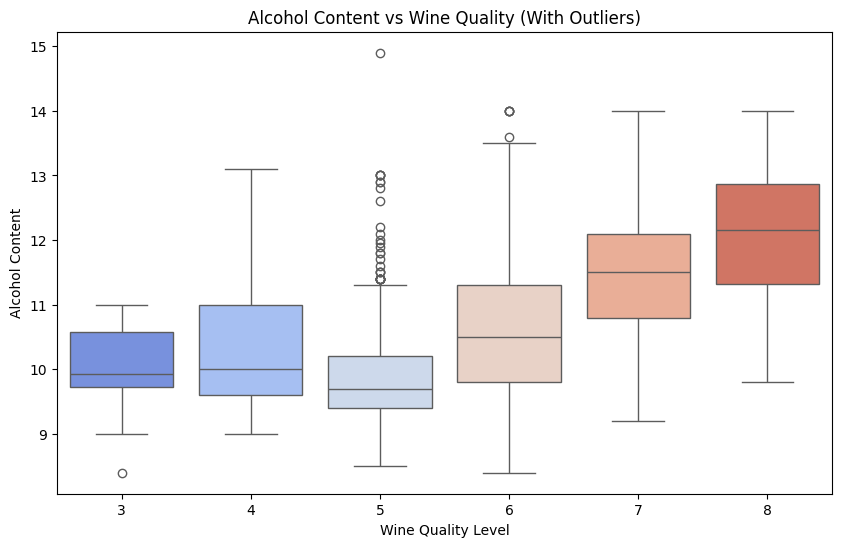

In [2]:
# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

# Example box plot for alcohol content across wine quality levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')
plt.title('Alcohol Content vs Wine Quality (With Outliers)')
plt.xlabel('Wine Quality Level')
plt.ylabel('Alcohol Content')
plt.show()


<Axes: >

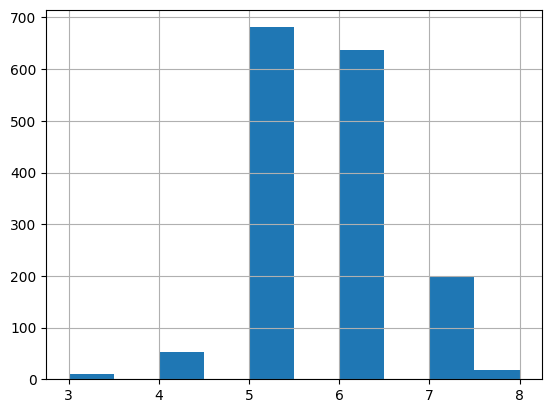

In [3]:
df['quality'].hist()

In [4]:
# initialize TomekLinks
# TomekLinks is used to reduce data overlap throughout the dataset
# howewer, we can't really configure its parameters
tomek = TomekLinks()

# X/y -split
X = df.drop("quality", axis=1)
y = df['quality']

# create new resampled versions of X and y
X_resampled, y_resampled = tomek.fit_resample(X, y)

# re-create a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled


In [5]:
df_resampled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1336,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1337,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1338,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_2832\2812027548.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df_resampled, palette='coolwarm')


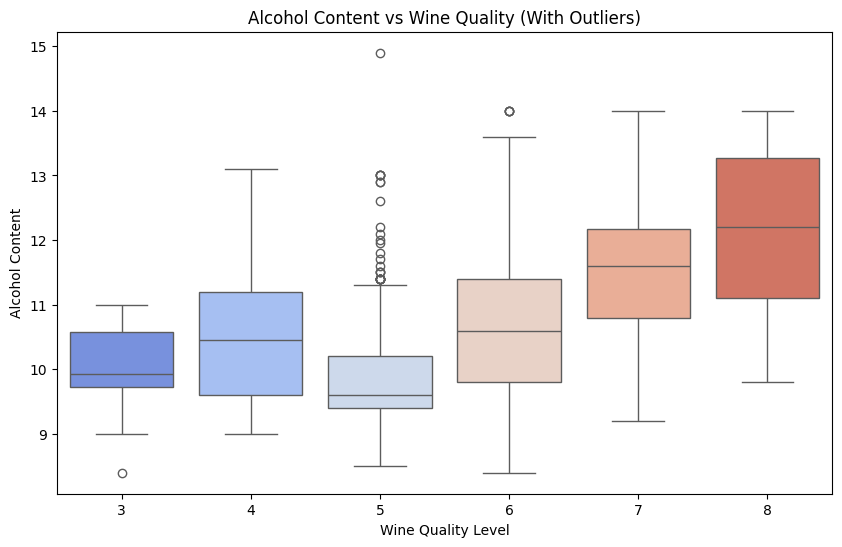

In [6]:
# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

# Example box plot for alcohol content across wine quality levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df_resampled, palette='coolwarm')
plt.title('Alcohol Content vs Wine Quality (With Outliers)')
plt.xlabel('Wine Quality Level')
plt.ylabel('Alcohol Content')
plt.show()


<Axes: >

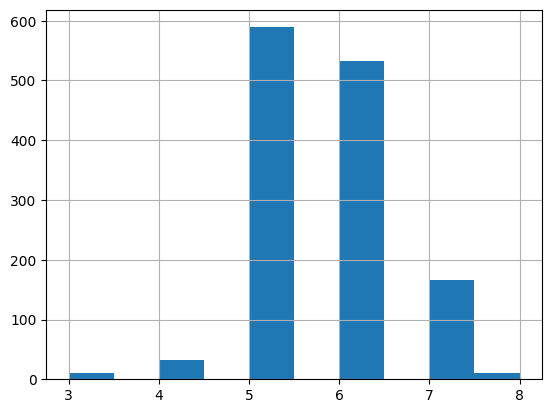

In [7]:
df_resampled['quality'].hist()

In [8]:
df_resampled['quality'].value_counts()

quality
5    589
6    533
7    166
4     32
8     10
3     10
Name: count, dtype: int64